# 02-3. MessagesState와 ToolNode로 만드는 Tool Agent

- 핵심 기술: `MessagesState`, 메시지 reducer, `ToolNode`, `tools_condition`, Agent Loop
- 최종 산출물: LLM이 Tool을 선택하고 `LLM → Tool → LLM`을 반복하는 LangGraph Tool Agent

## 1. 학습목표

이 실습을 완료하면 다음을 수행할 수 있다.

1. MessagesState와 메시지 reducer가 메시지를 누적하는 방식을 설명할 수 있다.
2. 규칙 기반 Routing(Notebook 02-2)과 LLM 기반 Tool Selection의 결정 주체 차이를 구분할 수 있다.
3. ToolNode와 tools_condition을 이용해 LLM과 Tool이 반복해서 상호작용하는 Agent Loop를 구성할 수 있다.
4. Tool 실행 후 결과를 다시 관찰하지 못하는 상황을 진단하고 올바르게 수정할 수 있다.

## 2. 문제 상황

Notebook 02-2는 `classify_input()`이라는 규칙이 입력을 미리 정해둔 네 가지 유형 중 하나로
분류하고, 그 결과에 따라 정해진 Node를 실행했다. 이 방식은 유형이 뚜렷하게 구분될 때는
빠르고 예측 가능하지만, "128을 4로 나눈 값과 보충 실습 열람 기간을 알려줘"처럼 하나의
요청 안에 계산과 문서 검색이 함께 섞여 있으면 어느 한 Node만으로는 처리할 수 없다. 필요한
Tool의 개수와 순서도 요청마다 달라진다.

이런 요청을 다루려면 개발자가 모든 조합을 미리 규칙으로 나열하는 대신, LLM이 현재 대화
내용과 Tool 설명을 보고 어떤 Tool을 호출할지, 언제 답변을 종료할지 스스로 판단해야 한다.
Notebook 01-3, 01-4에서 직접 구현했던 Tool Calling과 Agent Loop를 LangGraph의
MessagesState, ToolNode, tools_condition으로 다시 구성하는 것이 이번 실습의 핵심이다.

## 3. 핵심 개념

### 3.1 정의

MessagesState는 HumanMessage, AIMessage, ToolMessage를 순서대로 누적하는 LangGraph 내장
State이다. 내부의 메시지 reducer(`add_messages`)가 Node의 반환값을 기존 `messages` 뒤에
자동으로 이어붙이므로, 각 Node는 전체 메시지 목록이 아니라 새로 생긴 메시지만 반환하면
된다. ToolNode는 AIMessage에 담긴 `tool_calls`를 실제로 실행하고 그 결과를 ToolMessage로
변환하는 내장 Node이며, `tools_condition`은 마지막 메시지에 Tool Call이 남아 있는지를 보고
다음 경로(`"tools"` 또는 `END`)를 결정하는 내장 Router이다.

### 3.2 개념이 필요한 이유

요청마다 필요한 Tool의 종류와 횟수가 다르다면, 개발자가 실행 순서를 고정하는 방식으로는
대응할 수 없다. LLM이 현재까지의 메시지를 보고 Tool을 호출할지 답변을 종료할지 매번 다시
판단하고, 그 판단이 이전 Tool 결과를 반영해야 한다면 반복 가능한 Loop 구조가 필요하다.

### 3.3 주요 구성요소

| 구성요소 | 역할 |
|---|---|
| `MessagesState` | HumanMessage/AIMessage/ToolMessage를 순서대로 누적하는 State |
| `add_messages` reducer | Node가 반환한 새 메시지를 기존 `messages` 뒤에 자동으로 추가 |
| `agent_node` | 누적된 메시지를 모델에 전달해 응답(AIMessage) 하나를 생성 |
| `ToolNode` | `AIMessage.tool_calls`를 실행하고 결과를 ToolMessage로 생성 |
| `tools_condition` | 마지막 메시지의 `tool_calls` 유무로 `"tools"` 또는 `END`를 반환 |
| `SYSTEM_PROMPT` | 어떤 상황에 어떤 Tool을 사용할지 모델에게 지시하는 규칙 |

### 3.4 동작 과정

```text
HumanMessage 추가
  ↓
agent Node: 메시지를 관찰하고 답변 또는 Tool Call 생성
  │
  ├─ Tool Call 없음 → 최종 AIMessage 반환 → 종료
  │
  └─ Tool Call 있음
       ↓
     tools Node(ToolNode): Tool 실행 → ToolMessage 추가
       ↓
     agent Node로 복귀 (반복)
```

### 3.5 코드와 개념의 대응 관계

| 코드 요소 | 구현 개념 |
|---|---|
| `MessagesState` | 메시지 누적 State |
| `agent_node()` | LLM 호출과 응답(Tool Call 또는 최종 답) 생성 |
| `ToolNode(TOOLS)` | Tool 실행과 ToolMessage 생성 |
| `tools_condition` | Tool 실행 여부를 판단하는 Router |
| `add_conditional_edges("agent", tools_condition)` | Tool 실행 여부에 따른 Conditional Edge |
| `add_edge("tools", "agent")` | Tool 결과를 LLM이 다시 관찰하도록 만드는 반복 Edge |

### 3.6 유사 개념과의 차이

**규칙 기반 Routing(02-2) vs LLM 기반 Tool Selection(02-3)**

| 구분 | 규칙 기반 Routing | LLM 기반 Tool Selection |
|---|---|---|
| 결정 주체 | 개발자가 작성한 조건문 | LLM이 Tool schema와 메시지를 보고 판단 |
| 결정 시점 | Node 실행 전 한 번 | Tool을 실행할 때마다 반복적으로 재판단 |
| 반복 여부 | 없음, 한 번 분기 후 결과 통합으로 합류 | 필요한 만큼 LLM → Tool → LLM 반복 |
| 예측 가능성 | 동일 입력 → 항상 동일 결과 | 모델 응답에 따라 달라질 수 있음 |

**단일 Tool Call vs 복수 Tool Call vs 반복 Tool Call**

| 구분 | 설명 |
|---|---|
| 단일 Tool Call | 하나의 AIMessage에 Tool Call이 하나만 있는 경우 |
| 복수 Tool Call | 하나의 AIMessage 안에 서로 독립적인 Tool Call이 여러 개 있는 경우 (6.2) |
| 반복 Tool Call | 여러 회차에 걸쳐 새 AIMessage가 생성되며 Tool을 다시 호출하는 경우 (6.1) |

### 3.7 사용 시점과 적용 조건

요청 유형이 다양하고 모호하며, 필요한 Tool의 개수나 호출 순서를 미리 정할 수 없을 때 Tool
Agent 구조를 사용한다. 처리 유형이 몇 가지로 뚜렷하게 나뉘고 규칙으로 분류할 수 있다면
Notebook 02-2의 Router로 충분하다.

### 3.8 한계와 주의사항

- `tools → agent` Edge가 없으면 Tool 결과가 ToolMessage 상태로 남고 최종 답변으로
  이어지지 않는다.
- 논리적 종료 조건(Tool Call 없는 AIMessage)과는 별개로 `recursion_limit` 같은 안전장치가
  반드시 필요하다.
- Tool 설명(docstring)이 모호하면 모델이 적절한 Tool을 선택하지 못하거나, 같은 Tool을
  불필요하게 반복 호출할 수 있다.

### 3.9 자주 발생하는 오해

"ToolNode를 연결하면 Tool 선택 로직도 자동으로 안전해진다"는 오해가 있다. 실제로 어떤
Tool을 호출할지는 LLM이 SYSTEM_PROMPT와 Tool schema를 보고 결정하며, ToolNode는 이미
결정된 `tool_calls`를 실행하고 결과를 메시지로 만드는 역할만 담당한다.

### 3.10 핵심 정리

- MessagesState와 reducer는 메시지를 자동으로 누적하므로, Node는 전체 대화가 아니라 새
  메시지만 반환하면 된다.
- ToolNode는 Tool 실행을 담당하고, `tools_condition`은 다음 경로 판단을 담당하며, 이 둘의
  조합이 LLM → Tool → LLM 반복을 만든다.
- 02-2의 Routing은 개발자 규칙이 Node를 정하고, 이번 Tool Agent는 LLM이 Tool과 인자를
  정한다.
- `tools → agent` Edge 없이는 Tool 결과가 최종 답변에 반영되지 않는다.

## 4. 실행 구조

```text
START
  │
  ▼
agent Node ── AIMessage에 Tool Call 없음 ──▶ END
  │
  │ AIMessage에 Tool Call 있음
  ▼
tools Node (ToolNode)
  │
  │ ToolMessage 누적
  └────────────────────────────────────────▶ agent Node
```

01-3~01-4의 수동 Loop와 대응시키면 다음과 같다.

| 수동 Agent Loop | LangGraph 구현 |
|---|---|
| Plan | `agent` Node의 LLM 호출 |
| Act | `ToolNode` |
| Observe | `ToolMessage`가 `MessagesState`에 누적 |
| Evaluate / Continue | `tools_condition`과 다음 LLM 호출 |
| 반복문 | `tools → agent` Edge |

## 5. 환경 설정

반복되는 경로 탐색과 모델 생성 코드는 `src/agentic_ai` 공통 모듈에서 관리한다.
아래 셀에서는 이 Notebook에 필요한 표준 라이브러리와 공통 기능만 불러온다.

> 처음 실행하거나 환경 오류가 발생하면 프로젝트 루트의
> `00_environment_check.ipynb`를 먼저 실행한다.


In [1]:
import json

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

from agentic_ai.config import get_settings
from agentic_ai.logging_utils import save_log
from agentic_ai.models import get_chat_model
from agentic_ai.notebook_utils import print_environment_summary, show_graph
from agentic_ai.paths import OUTPUT_DIR
from agentic_ai.tools import calculate, search_keyword

settings = get_settings()
print_environment_summary(settings, needs_chat_model=True)


[환경 설정 확인]
- 프로젝트: E:\agentic_ai_lab
- 데이터: E:\agentic_ai_lab\data
- 출력: E:\agentic_ai_lab\outputs
- OPENAI_API_KEY: 설정됨
- Chat Model: gpt-4.1-mini


## 6. 최소 실행 예제

먼저 Agent가 사용할 Tool을 정의한다. Tool의 이름, 설명, 매개변수 schema가 LLM의 선택 기준이 되므로 docstring을 구체적으로 작성한다.

In [2]:
COURSE_POLICY = (
    "수료 기준은 출석률 80% 이상이며, 최종 프로젝트를 제출해야 한다. "
    "보충 실습은 과정 종료 후 14일 동안 열람할 수 있다."
)


# 함수 시그니처와 Docstring이 모델의 Tool 선택에 사용되는 Schema가 된다.
@tool
def calculate_tool(expression: str) -> float:
    """사칙연산 수식을 안전하게 계산한다. 숫자 계산이 필요할 때 사용한다."""
    return calculate(expression)


@tool
def search_course_policy_tool(keyword: str) -> str:
    """교육과정의 출석, 수료, 프로젝트, 보충 실습 규정에서 키워드를 검색한다."""
    result = search_keyword(COURSE_POLICY, keyword)
    if not result["found"]:
        return f"'{keyword}' 관련 규정을 찾지 못했습니다."
    position = result["position"]
    start = max(0, position - 12)
    end = min(len(COURSE_POLICY), position + len(keyword) + 28)
    return COURSE_POLICY[start:end]


TOOLS = [calculate_tool, search_course_policy_tool]
for registered_tool in TOOLS:
    print(registered_tool.name, "-", registered_tool.description)

calculate_tool - 사칙연산 수식을 안전하게 계산한다. 숫자 계산이 필요할 때 사용한다.
search_course_policy_tool - 교육과정의 출석, 수료, 프로젝트, 보충 실습 규정에서 키워드를 검색한다.


### 6.1 여러 회차에 걸친 반복 Tool Call

LLM의 응답 변동과 관계없이 Loop 자체를 관찰하기 위해 결정적인 `scripted_agent`를 먼저 사용한다. 첫 번째 Tool 결과를 받은 뒤 두 번째 Tool을 호출하고, 두 번째 결과까지 받으면 최종 답을 만든다. 실제 LLM Agent도 같은 메시지 계약을 사용한다.

In [3]:
def scripted_agent(state: MessagesState) -> dict:
    """128 / 4 후 그 결과에 17을 더하는 결정적 Agent 예제."""
    # 전체 메시지 중 Tool 실행 결과만 골라 현재 계산 단계를 판단한다.
    observations = [
        message for message in state["messages"]
        if isinstance(message, ToolMessage)
    ]

    # AIMessage의 tool_calls는 실행 결과가 아니라 ToolNode에 보내는 실행 요청이다.
    if len(observations) == 0:
        response = AIMessage(
            content="",
            tool_calls=[{
                "name": "calculate_tool",
                "args": {"expression": "128 / 4"},
                "id": "step-1",
                "type": "tool_call",
            }],
        )
    elif len(observations) == 1:
        first_value = observations[0].content
        response = AIMessage(
            content="",
            tool_calls=[{
                "name": "calculate_tool",
                "args": {"expression": f"{first_value} + 17"},
                "id": "step-2",
                "type": "tool_call",
            }],
        )
    else:
        response = AIMessage(content=f"최종 계산 결과는 {observations[-1].content}입니다.")

    # MessagesState의 reducer가 새 메시지를 기존 대화 기록 뒤에 누적한다.
    return {"messages": [response]}


scripted_builder = StateGraph(MessagesState)
scripted_builder.add_node("agent", scripted_agent)
scripted_builder.add_node("tools", ToolNode(TOOLS))
scripted_builder.add_edge(START, "agent")
# Tool Call이 있으면 tools로, 없으면 END로 보내는 조건부 Edge다.
scripted_builder.add_conditional_edges("agent", tools_condition)
# Tool 결과를 다시 agent가 관찰해야 다음 호출이나 최종 답변을 결정할 수 있다.
scripted_builder.add_edge("tools", "agent")
scripted_graph = scripted_builder.compile()



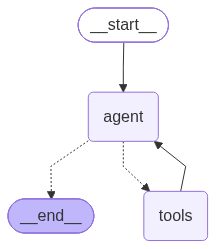

In [4]:
# 시각화는 네트워크 환경에 따라 실패할 수 있으므로 선택적으로 실행한다.
show_graph(scripted_graph)

In [5]:
# 논리적 종료에 실패하더라도 Graph가 무한히 순환하지 않도록 반복 상한을 둔다.
scripted_result = scripted_graph.invoke(
    {"messages": [HumanMessage(content="128을 4로 나눈 뒤 17을 더해줘.")]},
    config={"recursion_limit": 10},
)
for message in scripted_result["messages"]:
    print(type(message).__name__, "|", message.content, getattr(message, "tool_calls", ""))

HumanMessage | 128을 4로 나눈 뒤 17을 더해줘. 
AIMessage |  [{'name': 'calculate_tool', 'args': {'expression': '128 / 4'}, 'id': 'step-1', 'type': 'tool_call'}]
ToolMessage | 32.0 
AIMessage |  [{'name': 'calculate_tool', 'args': {'expression': '32.0 + 17'}, 'id': 'step-2', 'type': 'tool_call'}]
ToolMessage | 49.0 
AIMessage | 최종 계산 결과는 49.0입니다. []


**결과 해석**: `AIMessage → ToolMessage → AIMessage → ToolMessage → AIMessage` 순서가 나타난다. 이것이 Notebook 01-4의 반복문을 Graph로 옮긴 모습이다. 마지막 `AIMessage`에 Tool Call이 없기 때문에 `tools_condition`이 `END`를 선택한다.

### 6.2 하나의 AIMessage에 포함된 복수 Tool Call

서로 독립적인 작업이라면 LLM은 한 번에 여러 Tool Call을 만들 수 있다. 다음 셀은 Tool 선택 결과를 직접 만들어 `ToolNode`가 두 요청을 모두 실행하는지 결정적으로 확인한다.

In [6]:
# 하나의 AIMessage가 서로 독립적인 Tool Call 여러 개를 동시에 요청할 수 있다.
multi_call_message = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "calculate_tool",
            "args": {"expression": "25 + 17"},
            "id": "multi-1",
            "type": "tool_call",
        },
        {
            "name": "search_course_policy_tool",
            "args": {"keyword": "수료"},
            "id": "multi-2",
            "type": "tool_call",
        },
    ],
)

# ToolNode는 LangGraph Runtime 안에서 실행되므로 최소 Graph에 연결해 확인한다.
multi_builder = StateGraph(MessagesState)
multi_builder.add_node("tools", ToolNode(TOOLS))
multi_builder.add_edge(START, "tools")
multi_builder.add_edge("tools", END)
multi_graph = multi_builder.compile()

multi_result = multi_graph.invoke({"messages": [multi_call_message]})
multi_tool_messages = [
    message for message in multi_result["messages"]
    if isinstance(message, ToolMessage)
]
for tool_message in multi_tool_messages:
    print(tool_message.name, "->", tool_message.content, "/ call_id:", tool_message.tool_call_id)

calculate_tool -> 42 / call_id: multi-1
search_course_policy_tool -> 수료 기준은 출석률 80% 이상이며, 최종 프로젝트를  / call_id: multi-2


## 7. 단계별 구현

### 7.1 Tool을 LLM에 연결하고 Agent Node 작성

Agent Node는 누적된 메시지를 모델에 전달하고 새 `AIMessage` 하나만 반환한다. Tool 결과가 이미 메시지 목록에 있으므로 모델은 이를 관찰한 뒤 최종 답을 하거나 다음 Tool을 호출할 수 있다.

In [7]:
SYSTEM_PROMPT = """당신은 교육과정 지원 Tool Agent다.
- 숫자 계산은 반드시 calculate_tool을 사용한다.
- 출석, 수료, 프로젝트, 보충 실습 규정은 search_course_policy_tool을 사용한다.
- 서로 독립적인 작업은 필요한 Tool을 모두 호출해도 된다.
- ToolMessage에 필요한 결과가 이미 있으면 같은 Tool을 불필요하게 반복 호출하지 않는다.
- Tool 결과를 확인한 뒤 한국어로 간결한 최종 답을 작성한다."""

model = get_chat_model()
# bind_tools는 선택 가능한 Schema를 모델에 제공하며 실제 실행은 ToolNode가 담당한다.
model_with_tools = model.bind_tools(TOOLS)


def agent_node(state: MessagesState) -> dict:
    """현재 메시지를 보고 답변하거나 다음 Tool Call을 생성한다."""
    # 매 회차 전체 메시지 기록을 전달해야 모델이 이전 Tool 결과를 관찰할 수 있다.
    response = model_with_tools.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        *state["messages"],
    ])
    return {"messages": [response]}

### 7.2 Tool Agent Graph 조립

**TODO**: `build_tool_agent_graph()`를 완성한다.

- `StateGraph(MessagesState)`를 생성한다.
- `agent_node`와 `ToolNode(TOOLS)`를 각각 `agent`, `tools`로 등록한다.
- `START → agent`를 연결한다.
- `agent` 다음 경로는 `tools_condition`으로 결정한다.
- Tool 실행 결과를 모델이 다시 관찰하도록 `tools → agent`를 연결한다.

In [8]:
def build_tool_agent_graph():
    """LLM이 Tool을 선택하고 결과를 다시 관찰하는 Agent Graph를 만든다."""
    builder = StateGraph(MessagesState)
    builder.add_node("agent", agent_node)
    # Tool 예외도 ToolMessage로 돌려주면 agent가 실패를 관찰하고 대응할 수 있다.
    builder.add_node("tools", ToolNode(TOOLS, handle_tool_errors=True))
    builder.add_edge(START, "agent")
    builder.add_conditional_edges("agent", tools_condition)
    builder.add_edge("tools", "agent")
    return builder.compile()


tool_agent_graph = build_tool_agent_graph()
print("Tool Agent Graph 생성 완료")

Tool Agent Graph 생성 완료


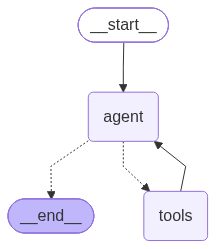

In [9]:
# 시각화는 네트워크 환경에 따라 실패할 수 있으므로 선택적으로 실행한다.
show_graph(tool_agent_graph)

### 7.3 Invoke

계산과 규정 검색을 함께 요청한다. 모델이 두 Tool을 한 번에 호출할 수도 있고, 하나씩 순서대로 호출할 수도 있다. 두 방식 모두 필요한 근거를 수집하고 최종 답에 도달하면 올바른 Agent 실행이다.

In [10]:
agent_request = "25와 17을 더하고, 과정의 수료 기준도 알려줘."
agent_result = tool_agent_graph.invoke(
    {"messages": [HumanMessage(content=agent_request)]},
    config={"recursion_limit": 10},
)

for message in agent_result["messages"]:
    print(f"[{type(message).__name__}] {message.content}")
    if isinstance(message, AIMessage) and message.tool_calls:
        print("  tool_calls:", message.tool_calls)

[HumanMessage] 25와 17을 더하고, 과정의 수료 기준도 알려줘.
[AIMessage] 
  tool_calls: [{'name': 'calculate_tool', 'args': {'expression': '25 + 17'}, 'id': 'call_cVOs972pY4sggEvGbuTpnnu8', 'type': 'tool_call'}, {'name': 'search_course_policy_tool', 'args': {'keyword': '수료 기준'}, 'id': 'call_mqn0pHBN1XW4avdlBmQWd77K', 'type': 'tool_call'}]
[ToolMessage] 42
[ToolMessage] 수료 기준은 출석률 80% 이상이며, 최종 프로젝트를 제출해
[AIMessage] 25와 17을 더한 값은 42입니다. 과정의 수료 기준은 출석률 80% 이상이며, 최종 프로젝트를 제출하는 것입니다.


## 8. 실행 과정 관찰

최종 State만 보면 Loop의 중간 과정이 잘 보이지 않는다. `stream_mode="updates"`로 어느 Node가 어떤 메시지를 추가했는지 관찰한다.

In [11]:
trace_request = "128을 4로 나눈 값과 보충 실습 열람 기간을 알려줘."
trace_events = []

# updates 모드는 각 Node가 실행 직후 반환한 부분 State만 단계별로 보여준다.
for update in tool_agent_graph.stream(
    {"messages": [HumanMessage(content=trace_request)]},
    config={"recursion_limit": 10},
    stream_mode="updates",
):
    trace_events.append(update)
    for node_name, node_update in update.items():
        messages = node_update.get("messages", [])
        print(f"NODE: {node_name}")
        for message in messages:
            print(" ", type(message).__name__, "|", message.content)
            if isinstance(message, AIMessage) and message.tool_calls:
                print("   tool_calls:", message.tool_calls)

NODE: agent
  AIMessage | 
   tool_calls: [{'name': 'calculate_tool', 'args': {'expression': '128 / 4'}, 'id': 'call_CS2bASBXVda25iSZEZ2BEA6V', 'type': 'tool_call'}, {'name': 'search_course_policy_tool', 'args': {'keyword': '보충 실습 열람 기간'}, 'id': 'call_pgR5PY36XbGK8LzquiwXwWfa', 'type': 'tool_call'}]
NODE: tools
  ToolMessage | 32.0
  ToolMessage | '보충 실습 열람 기간' 관련 규정을 찾지 못했습니다.
NODE: agent
  AIMessage | 128을 4로 나눈 값은 32입니다. 다만, 보충 실습 열람 기간에 관한 규정은 찾을 수 없습니다.


**관찰 포인트**

- `agent`가 생성한 `AIMessage.tool_calls`에 Tool 이름과 인자가 들어 있는가?
- `tools`가 같은 `tool_call_id`를 가진 `ToolMessage`를 생성하는가?
- Tool 실행 뒤 다시 `agent`가 실행되는가?
- 마지막 `AIMessage`에는 Tool Call이 없고 자연어 답변만 있는가?
- 독립적인 두 요청이 한 번의 복수 Tool Call인지 여러 회차 호출인지 모델에 따라 비교한다.

## 9. 실패 실험: Tool 실행 후 바로 종료하기

`tools → agent` Edge를 `tools → END`로 잘못 연결하면 Tool은 실행되지만 LLM이 결과를 다시 읽지 못한다. 모델 변동 없이 현상을 확인하기 위해 앞의 `scripted_agent`를 사용한다.

In [12]:
broken_builder = StateGraph(MessagesState)
broken_builder.add_node("agent", scripted_agent)
broken_builder.add_node("tools", ToolNode(TOOLS))
broken_builder.add_edge(START, "agent")
broken_builder.add_conditional_edges("agent", tools_condition)
# tools에서 바로 끝내면 ToolMessage를 agent가 읽지 못해 최종 자연어 답변이 생성되지 않는다.
broken_builder.add_edge("tools", END)  # 잘못된 연결
broken_graph = broken_builder.compile()

broken_result = broken_graph.invoke({
    "messages": [HumanMessage(content="128을 4로 나눈 뒤 17을 더해줘.")]
})
print("마지막 메시지 유형:", type(broken_result["messages"][-1]).__name__)
print("마지막 메시지 내용:", broken_result["messages"][-1].content)

마지막 메시지 유형: ToolMessage
마지막 메시지 내용: 32.0


**원인 분석**

마지막 메시지가 `ToolMessage`인 상태에서 실행이 끝난다. Tool 결과는 사용자에게 전달할 최종 답변이 아니라 LLM이 관찰할 데이터다. 따라서 Tool 실행 뒤에는 `agent` Node로 돌아가야 한다. `tools_condition`만 추가한다고 Loop가 완성되는 것이 아니라 돌아가는 Edge도 필요하다.

## 10. 오류 수정 실습

`tools → agent`로 수정한 뒤 두 번의 Tool Call과 최종 답변까지 도달하는지 재검증한다.

In [13]:
fixed_builder = StateGraph(MessagesState)
fixed_builder.add_node("agent", scripted_agent)
fixed_builder.add_node("tools", ToolNode(TOOLS))
fixed_builder.add_edge(START, "agent")
fixed_builder.add_conditional_edges("agent", tools_condition)
fixed_builder.add_edge("tools", "agent")
fixed_graph = fixed_builder.compile()

fixed_result = fixed_graph.invoke(
    {"messages": [HumanMessage(content="128을 4로 나눈 뒤 17을 더해줘.")]},
    config={"recursion_limit": 10},
)
print("마지막 메시지 유형:", type(fixed_result["messages"][-1]).__name__)
print("최종 답변:", fixed_result["messages"][-1].content)
print("ToolMessage 수:", sum(isinstance(m, ToolMessage) for m in fixed_result["messages"]))

마지막 메시지 유형: AIMessage
최종 답변: 최종 계산 결과는 49.0입니다.
ToolMessage 수: 2


## 11. 도전 과제

1. 현재 시간을 반환하는 `get_current_time_tool`을 추가하고 모델이 적절히 선택하는지 확인한다.
2. `calculate_tool`에 잘못된 수식을 전달해 `handle_tool_errors=True`일 때 모델이 오류를 어떻게 관찰하는지 확인한다.
3. System Prompt에서 "같은 Tool을 불필요하게 반복 호출하지 않는다" 규칙을 제거하고 행동이 달라지는지 비교한다.
4. `recursion_limit`을 작게 설정해 반복 제한이 Agent Loop의 최종 안전장치로 어떻게 작동하는지 확인한다.
5. `MessagesState` 대신 `Annotated[list, add_messages]`를 사용한 사용자 정의 State를 작성하고 둘의 관계를 비교한다.

## 12. 테스트

**테스트 유형: 로컬 Graph 통합 테스트 — 결정적, 외부 API 호출 없음**

Scripted Agent로 `tools_condition`, `ToolNode`와 Agent Loop 구조를 검증한다.

In [14]:
tool_route_message = AIMessage(
    content="",
    tool_calls=[{
        "name": "calculate_tool",
        "args": {"expression": "1 + 1"},
        "id": "test-1",
        "type": "tool_call",
    }],
)
end_route_message = AIMessage(content="완료")

assert tools_condition({"messages": [tool_route_message]}) == "tools"
assert tools_condition({"messages": [end_route_message]}) == END
assert len(multi_tool_messages) == 2
assert {message.name for message in multi_tool_messages} == {
    "calculate_tool", "search_course_policy_tool"
}
assert isinstance(broken_result["messages"][-1], ToolMessage)
assert isinstance(fixed_result["messages"][-1], AIMessage)
assert sum(isinstance(m, ToolMessage) for m in fixed_result["messages"]) == 2
assert "49" in fixed_result["messages"][-1].content
print("Tool Agent 구조 테스트 통과")

Tool Agent 구조 테스트 통과


## 13. 결과 저장

In [15]:
def message_to_log(message) -> dict:
    """LangChain Message를 JSON 저장 가능한 형태로 변환한다."""
    # 메시지 객체 자체는 JSON 직렬화 대상이 아니므로 필요한 속성만 기본 자료형으로 꺼낸다.
    return {
        "type": type(message).__name__,
        "content": str(message.content),
        "tool_calls": getattr(message, "tool_calls", []),
        "tool_call_id": getattr(message, "tool_call_id", None),
        "name": getattr(message, "name", None),
    }


tool_agent_log = {
    "request": agent_request,
    "messages": [message_to_log(message) for message in agent_result["messages"]],
    "tool_message_count": sum(
        isinstance(message, ToolMessage) for message in agent_result["messages"]
    ),
    "trace_node_sequence": [next(iter(event)) for event in trace_events],
}
saved_path = save_log(
    tool_agent_log,
    OUTPUT_DIR / "logs" / "02-3_langgraph_tool_agent_log.json",
)
print("저장 완료:", saved_path)

저장 완료: E:\agentic_ai_lab\outputs\logs\02-3_langgraph_tool_agent_log.json


## 14. 핵심 정리

- Notebook 02-2의 Router는 개발자가 작성한 규칙으로 Node를 선택하고, 이번 Tool Agent는 LLM이 Tool schema를 보고 Tool과 인자를 선택한다.
- `MessagesState`는 메시지 reducer를 통해 `HumanMessage`, `AIMessage`, `ToolMessage`를 순서대로 누적한다.
- `ToolNode`는 Tool Call 실행과 `ToolMessage` 생성을 담당한다.
- `tools_condition`은 마지막 AI 메시지의 Tool Call 유무를 보고 `tools` 또는 `END`를 선택한다.
- `tools → agent` Edge가 있어야 LLM이 Tool 결과를 관찰하고 추가 행동이나 최종 답을 결정한다.
- 하나의 AI 메시지에 복수 Tool Call이 포함될 수 있고, 여러 회차에 걸쳐 Tool을 반복 호출할 수도 있다.
- 논리적 종료 조건과 별도로 `recursion_limit` 같은 안전장치가 필요하다.

## 15. 확인 문제

1. Notebook 02-2의 규칙 기반 Routing과 이번 실습의 Tool Selection은 결정 주체가 어떻게 다른가?
2. `MessagesState`의 Node가 전체 메시지 대신 새 메시지만 반환해야 하는 이유는 무엇인가?
3. `ToolNode`와 `tools_condition`은 각각 어떤 역할을 하는가?
4. `tools → END`로 연결하면 왜 최종 자연어 답변을 얻기 어려운가?
5. 복수 Tool Call과 반복 Tool Call은 무엇이 다른가?
6. `recursion_limit`은 Agent의 논리적 종료 조건을 대신할 수 있는가?